#Mount to Drive/ Set libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/KAIST/25_01/NLP

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/KAIST/25_01/NLP


In [ ]:
!pip install nltk konlpy wordcloud matplotlib
# Changing NumPy version for Gensim use
!pip install numpy==1.26.4 -q
!pip install gensim -q
!pip install bertopic -q
!pip install pyLDAvis -q
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!After executing this cell, go to Menu -> Runtime -> Restart session!!!!!!!!!!!!!!!!!!!!!!
!pip install bertopic

In [ ]:
import pandas as pd
from konlpy.tag import Okt
import re
from nltk.corpus import stopwords
from gensim import corpora, models
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
import matplotlib.pyplot as plt
import nltk
from nltk import FreqDist

# Weverse

In [ ]:
# 1. Load CSV
df = pd.read_csv("weverse_full.csv")
df = df.dropna(subset=["content"])
texts = df["content"].tolist()

In [ ]:
df

,content,created_time,likes,comments
0,자기전에 리셋하고 지금까지 안끊긴건 처음이야 🥹\n🍈 낯설다 너...,2024-05-29 10:50,0,0
1,"요며칠 스밍 하면서 만들었던\n멤버들 비즈팔찌,목걸이,키링(?̊̈ )들\n똑같지는 ...",2024-05-29 10:48,2,0
2,굿모닝 입니당💙💜💗❤️🖤 \nㅊㅇㄷ 6자리 비었어요 🙇🏻‍♀️\n➡️minny654...,2024-05-29 10:46,2,0
3,뉴플리 오늘 재화 다털었습니다\n아주 탈탈탈.. 내일부터 다시 모아야겠죠^^;;;;...,2024-05-29 10:44,4,0
4,오늘 마감인 투표 100% 상도 함께 해주세요🤍 [18:59종료] ❗️\n뒤늦게 🍇...,2024-05-29 10:28,15,0
...,...,...,...,...
23673,"리셋완료.\n항상 스밍,투표 그리고 독려해주시는 플리님들 감사합니다🤍",2024-04-12 02:01,20,0
23674,스밍을 왜 해야하냐며는요\n스밍을 해야 멤버들 음원 성적에 도움이 되고요\n길거리에...,2024-04-12 02:00,20,0
23675,심괴 시청기록에서 삭제 까지 완료🤭\n나플리의 알고리즘은 플레이브만 허용가능합니다ㅎ...,2024-04-12 01:38,19,0
23676,은호야 오늘 하루도 수고했엉\n아무 꿈도 꾸지 말고 푹 자 사랑해❤️,2024-04-12 01:36,19,0


In [ ]:
# 2. Initialize tokenizer
okt = Okt()
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# 3. Preprocess function
def clean_text(text):
    text = re.sub(r'[^\uAC00-\uD7A3\s]', '', text)  # remove non-Korean
    tokens = okt.nouns(text)
    stop_words = set(stopwords.words('korean')) if 'korean' in stopwords.fileids() else set()
    return [t for t in tokens if len(t) > 1 and t not in stop_words]

# 4. Apply preprocessing
cleaned_texts = [clean_text(text) for text in texts]
cleaned_texts = [text for text in cleaned_texts if len(text) > 0]

# 5. Create dictionary and corpus
dictionary = corpora.Dictionary(cleaned_texts)
corpus = [dictionary.doc2bow(text) for text in cleaned_texts]


In [ ]:
# 6. LDA modeling
lda_model = models.LdaModel(corpus, num_topics=5, id2word=dictionary, passes=10, random_state=42)


In [ ]:
# 7. Show topics
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

# 8. Visualize with pyLDAvis
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
vis

Topic 0: 0.045*"스밍" + 0.043*"차트" + 0.026*"보기" + 0.025*"순위" + 0.015*"컴백" + 0.014*"플리" + 0.010*"대쉬" + 0.010*"프리징" + 0.010*"아웃" + 0.009*"설정"
Topic 1: 0.092*"투표" + 0.032*"시간" + 0.018*"하트" + 0.016*"광고" + 0.015*"플리" + 0.012*"보기" + 0.011*"오후" + 0.010*"어디" + 0.010*"재화" + 0.009*"라인"
Topic 2: 0.035*"보기" + 0.033*"사랑" + 0.031*"우리" + 0.025*"오늘" + 0.025*"은호" + 0.023*"진짜" + 0.023*"예준" + 0.017*"생일" + 0.017*"노아" + 0.015*"밤비"
Topic 3: 0.049*"플리" + 0.049*"스밍" + 0.017*"보기" + 0.014*"우리" + 0.014*"레이브" + 0.013*"지금" + 0.013*"생각" + 0.010*"진짜" + 0.009*"하나" + 0.009*"시작"
Topic 4: 0.098*"리셋" + 0.090*"오늘" + 0.046*"플리" + 0.045*"수고" + 0.043*"완료" + 0.025*"하루" + 0.021*"스밍" + 0.020*"내일" + 0.019*"고생" + 0.015*"인증"


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.016227  0.048546       1        1  30.921730
2     -0.216136  0.205252       2        1  20.763399
4     -0.182435 -0.270384       3        1  19.547104
0      0.236461 -0.090222       4        1  15.035632
1      0.145883  0.106807       5        1  13.732134, topic_info=    Term         Freq        Total Category  logprob  loglift
0     리셋  3862.000000  3862.000000  Default  30.0000  30.0000
19    오늘  4624.000000  4624.000000  Default  29.0000  29.0000
36    투표  2808.000000  2808.000000  Default  28.0000  28.0000
286   수고  1797.000000  1797.000000  Default  27.0000  27.0000
76    완료  1691.000000  1691.000000  Default  26.0000  26.0000
..   ...          ...          ...      ...      ...      ...
589  플레이   101.386293   193.306944   Topic5  -5.6119   1.3401
66    어제   108.627127   501.421983   Topic5  -5.5429   0.4559
342   보고   111.502244   661.607188   Topic5  -5.5167   0.2048
377   위해   101.525371   390.726397   Topic5  -5.6105   0.6377
90    진짜   102.023069  1806.644080   Topic5  -5.6056  -0.8886

[277 rows x 6 columns], token_table=      Topic      Freq Term
term                      
264       4  0.997157   가능
626       4  0.995848  가이드
24        1  0.997723   가입
1323      1  0.995364   가지
486       2  0.994086   감기
...     ...       ...  ...
57        1  0.274632   확인
57        3  0.002497   확인
57        4  0.561748   확인
57        5  0.162283   확인
299       1  0.997333   활동

[343 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 3, 5, 1, 2])

## Complex version

In [ ]:
# Step 1: Advanced preprocessing setup
okt = Okt()

# Fan slang normalization dictionary
fan_slang_dict = {
    "스밍": "스트리밍",
    "플리": "팬",
    "재화": "포인트",
    "우주폰": "스밍폰",
    "공폰": "공용폰",
    "사과폰": "아이폰",
    "심괴": "심야괴담회",
    "멤버": "멤버",
    "뉴플리": "팬",
    "탈탈탈": "완전"
}

# Custom stopwords (expandable later)
custom_stopwords = set([
    "정말", "그리고", "이번", "오늘", "내일", "하는", "있어요", "했습니다",
    "자기", "지금", "조금", "같아요", "ㅠㅠ", "ㅎㅎ", "ㅋㅋ", "더보기",
    "하다", "있다", "보다","보기","들다","너무","되다","이다","우리","해주다",
    "으로","진짜","수고","같다","아니다","완료","자다","많이","않다",'오다','하고','없다',
    '까지','쓰다','그렇다','가다','해보다','싶다','알다','받다'
])

# Function to clean and normalize text
def preprocess_text(text):
    text = re.sub(r"[^\w\s]", " ", text)  # remove punctuation/symbols
    text = re.sub(r"\s+", " ", text)  # normalize spaces
    text = re.sub(r"(.)\1{2,}", r"\1", text)  # reduce repeated characters
    for slang, norm in fan_slang_dict.items():
        text = text.replace(slang, norm)
    return text.strip()

# Apply preprocessing
df["cleaned"] = df["content"].apply(preprocess_text)

# Tokenization with Okt
df["tokens"] = df["cleaned"].apply(lambda x: [word for word in okt.morphs(x, stem=True)
                                              if word not in custom_stopwords and len(word) > 1])
# Flatten and show top 50 frequent tokens for optional stopword refinement
all_tokens = sum(df["tokens"].tolist(), [])
fdist = FreqDist(all_tokens)
top_50_words = fdist.most_common(50)



In [ ]:
df["tokens_noun"] = df["cleaned"].apply(lambda x: [w for w, t in okt.pos(x) if t in ['Noun', 'Adjective'] and w not in custom_stopwords])

In [ ]:
# Gensim LDA
from gensim import corpora, models

# Prepare dictionary and corpus
dictionary = corpora.Dictionary(df["tokens"])
corpus = [dictionary.doc2bow(text) for text in df["tokens"]]

# Train LDA model
lda_model = models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes=10)

# Show topics
topics = lda_model.print_topics(num_words=10)
for i, topic in topics:
    print(f"Topic {i}: {topic}")

Topic 0: 0.041*"투표" + 0.013*"하트" + 0.012*"넣다" + 0.010*"모으다" + 0.008*"ㅊㅇㄷ" + 0.007*"광고" + 0.007*"포인트" + 0.007*"밤비" + 0.006*"앨범" + 0.006*"에서"
Topic 1: 0.044*"스트리밍" + 0.009*"생각" + 0.008*"에서" + 0.008*"레이브" + 0.008*"좋다" + 0.007*"차트" + 0.006*"시작" + 0.006*"많다" + 0.006*"분들" + 0.006*"모르다"
Topic 2: 0.016*"you" + 0.014*"100" + 0.012*"and" + 0.010*"도리" + 0.010*"to" + 0.010*"the" + 0.009*"PLAVE" + 0.009*"TOP" + 0.008*"https" + 0.007*"night"
Topic 3: 0.067*"리셋" + 0.035*"스트리밍" + 0.013*"인증" + 0.012*"시간" + 0.010*"차트" + 0.009*"현생" + 0.009*"많다" + 0.009*"화이팅" + 0.008*"투표" + 0.007*"https"
Topic 4: 0.026*"사랑" + 0.020*"좋다" + 0.019*"귀엽다" + 0.019*"먹다" + 0.016*"행복하다" + 0.015*"하루" + 0.015*"예준" + 0.014*"은호" + 0.011*"노아" + 0.011*"보내다"


In [ ]:
from bertopic import BERTopic
topic_model = BERTopic(language="multilingual")
topics, probs = topic_model.fit_transform(df["cleaned"])
topic_model.get_topic_info()

/usr/local/lib/python3.11/dist-packages/hdbscan/plots.py:448: DeprecationWarning: invalid escape sequence '\l'
  axis.set_ylabel('$\lambda$ value')
/usr/local/lib/python3.11/dist-packages/hdbscan/robust_single_linkage_.py:154: DeprecationWarning: invalid escape sequence '\{'
  """Perform robust single linkage clustering from a vector array
/usr/local/lib/python3.11/dist-packages/geopandas/_compat.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos
/usr/local/lib/python3.11/dist-packages/spacy/cli/_util.py:23: DeprecationWarning: Importing 'parser.split_arg_string' is deprecated, it will only be available in 'shell_completion' in Click 9.0.
  from click.parser import split_arg_string
/usr/local/lib/python3.11/dist-packages/weasel/util/config.py:8: DeprecationWarning: Importing 'parser.split_arg

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,12214,-1_보기_스트리밍_너무_우리,"[보기, 스트리밍, 너무, 우리, 오늘, 진짜, 리셋완, 오늘도, 리셋, 팬님들]",[자기전 마지막 리셋완 저는 이만 들어가보겠습니다 오늘 하루도 함께 해주신 모든 팬...
1,0,8485,0_너무_보기_오늘_생일,"[너무, 보기, 오늘, 생일, 우리, 리셋, 오늘도, 리셋완, 수고하셨습니다, 진짜]","[리셋완 오늘도 수고하셨습니다, 리셋완 오늘도 수고하셨습니다, 리셋완 오늘도 수고하..."
2,1,1455,1_투표_https_보기_kr,"[투표, https, 보기, kr, co, 스트리밍, vote, 투표는, 오늘, 투표도]","[리셋 완료 투표 수고하셨습니다, 투표 시작 https dctrend ai vote..."
3,2,859,2_스트리밍_보기_팬님들_차트,"[스트리밍, 보기, 팬님들, 차트, 음총팀, 00, 그리고, 같아요, dash, 많은]",[혹시 나는 스트리밍돌리구 싶은데 여건이 안돼시면 ㄷㅇ 음총팀 카페 가입해보세요 열...
4,3,225,3_설정_반복_무음으로_스트리밍,"[설정, 반복, 무음으로, 스트리밍, 알람, 미반영, 스밍폰, 음량, 안하면, 아이폰]",[모여봐요 스트리밍의 숲 안녕하세요 스트리밍하려는 팬님 찾아주셔서 감사합니다 스트리...
5,4,148,4_you_night_good_your,"[you, night, good, your, and, we, the, for, al...",[Good night Yejun You shine like a gentle star...
6,5,136,5_com_https_status_plavestream,"[com, https, status, plavestream, plave_stream...",[https usen oshireq com song 6517100 https ope...
7,6,112,6_top100_2025_top_기준,"[top100, 2025, top, 기준, 업데이트, 100, 00, hot100,...",[ㄹㅅ완료 2025 05 14 03 00 TOP100 프리징차트 순위 Dash TO...
8,7,31,7_shorts_youtube_si_com,"[shorts, youtube, si, com, https, rzwia1z_450,...",[https youtube com shorts MXNkacpNDpE si 1hxcL...
9,8,13,8_streaming_more_international_stream,"[streaming, more, international, stream, and, ...",[Hey international PLLIs let s stream together...


# Youtube

In [ ]:
# 1. Load CSV
df = pd.read_csv("plave_youtube_full.csv")
df = df.dropna(subset=["comment"])
texts = df["comment"].tolist()
df

,video_id,comment,likes,published
0,L5CirX1TNaA,밤비는 항상 귀여워~💗💗💗,0,2025-05-29T02:25:45Z
1,L5CirX1TNaA,かわいいすぎ🥹💗,0,2025-05-29T01:21:33Z
2,L5CirX1TNaA,めっちゃ可愛すぎる💗💕💗💕,0,2025-05-29T00:06:18Z
3,L5CirX1TNaA,🩷🩷🩷,0,2025-05-29T00:04:32Z
4,L5CirX1TNaA,💗💗💗💗💗,0,2025-05-28T23:34:52Z
...,...,...,...,...
382341,I0-kcqDKieQ,사랑스러워 ㅠㅠ,7,2023-04-28T04:07:21Z
382342,I0-kcqDKieQ,한노아 사랑해💜,21,2023-04-28T04:05:46Z
382343,I0-kcqDKieQ,어제 완전 귀요미였다!!!🥹\n노아 아프디마..기침할때마다 맴아푸다!애기들도 감기조...,41,2023-04-28T04:04:08Z
382344,I0-kcqDKieQ,1:01:22 초 울트라 킹왕짱 오나전 귀요미 아기 고양이 유하민 좌표.,10,2023-04-27T14:49:18Z


In [ ]:
# 2. Filter only comments published in April–May 2025
df['published'] = pd.to_datetime(df['published'])
df_filtered = df[(df['published'] >= "2025-04-01") & (df['published'] <= "2025-05-31")]

# 3. Keep only comments that contain Korean characters
def contains_korean(text):
    return bool(re.search(r"[가-힣]", text))

df = df_filtered[df_filtered["comment"].apply(contains_korean)]
df

,video_id,comment,likes,published
0,L5CirX1TNaA,밤비는 항상 귀여워~💗💗💗,0,2025-05-29 02:25:45+00:00
5,L5CirX1TNaA,바쁜 내향인 ㅋㅋㅋ,1,2025-05-28 22:13:05+00:00
6,L5CirX1TNaA,뵥뵥이 존재 자체가 귀여움 💗💗,1,2025-05-28 19:44:52+00:00
7,L5CirX1TNaA,앞으로 일만 남았으니 그렇게 알고 계세요! ㅋㅋㅋㅋ 웃기고 귀엽고 따듯해...💗💗💗,1,2025-05-28 17:38:25+00:00
10,L5CirX1TNaA,휴일 완전바쁘네 ㅋㅋㅋㅋㅋㅋ귀여워라 귀여움 체크 안 해서 더 최종귀여움,1,2025-05-28 16:21:13+00:00
...,...,...,...,...
381870,I0-kcqDKieQ,플둥이..님…귀여워…….ㅋㅋㅋㅋㅋ,0,2025-04-25 09:14:51+00:00
381871,I0-kcqDKieQ,진짜 남예준 살구송 미쳐따 진짜 오메 유리창 다 깨고싶다 진짜 애교력 미쳤다 으악,1,2025-04-15 13:57:53+00:00
381873,I0-kcqDKieQ,이날 한 방송에서 온갖 쇼츠영상이 다 터져나왔던 거구나 ㅋㅋㅋ그동안 봐왔던게 다 나...,4,2025-04-06 12:45:47+00:00
381874,I0-kcqDKieQ,ㅋㅋㅋㅋㅋㅋㅋㅋㅋ 팬덤명 후보가 엄청 많았구나 플리여서 좋지만 이브랑 플라워도 예뿐...,1,2025-04-06 06:22:46+00:00


In [ ]:
# 2. Initialize tokenizer
okt = Okt()
nltk.download("stopwords")

# 3. Preprocess function
def clean_text(text):
    text = re.sub(r'[^\uAC00-\uD7A3\s]', '', text)  # remove non-Korean
    tokens = okt.nouns(text)
    stop_words = set(stopwords.words('korean')) if 'korean' in stopwords.fileids() else set()
    return [t for t in tokens if len(t) > 1 and t not in stop_words]

# 4. Apply preprocessing
cleaned_texts = [clean_text(text) for text in texts]
cleaned_texts = [text for text in cleaned_texts if len(text) > 0]

# 5. Create dictionary and corpus
dictionary = corpora.Dictionary(cleaned_texts)
corpus = [dictionary.doc2bow(text) for text in cleaned_texts]

# 6. LDA modeling
lda_model = models.LdaModel(corpus, num_topics=5, id2word=dictionary, passes=10, random_state=42)

# 7. Show topics
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

# 8. Visualize with pyLDAvis
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
vis

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic 0: 0.211*"진짜" + 0.033*"봉구" + 0.025*"남예준" + 0.019*"하미" + 0.017*"우리" + 0.015*"대박" + 0.013*"유하" + 0.012*"막내" + 0.011*"아기" + 0.011*"제일"
Topic 1: 0.081*"사랑" + 0.074*"레이브" + 0.059*"노래" + 0.034*"우리" + 0.021*"플리" + 0.020*"정말" + 0.019*"축하" + 0.017*"항상" + 0.015*"아이돌" + 0.014*"생일"
Topic 2: 0.033*"방송" + 0.032*"영상" + 0.025*"오늘" + 0.021*"최고" + 0.018*"멤버" + 0.017*"노래" + 0.014*"생각" + 0.014*"보고" + 0.013*"라이브" + 0.012*"하나"
Topic 3: 0.147*"노아" + 0.027*"목소리" + 0.023*"마지막" + 0.019*"천재" + 0.017*"소리" + 0.016*"역시" + 0.015*"시작" + 0.015*"도은호" + 0.012*"왤케" + 0.012*"그냥"
Topic 4: 0.082*"예준" + 0.078*"밤비" + 0.062*"하민이" + 0.057*"진짜" + 0.053*"은호" + 0.014*"안무" + 0.014*"표정" + 0.012*"린지" + 0.010*"라인" + 0.010*"스포"


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.246748 -0.074974       1        1  25.387553
2      0.242784 -0.133432       2        1  23.287891
4     -0.222569 -0.091433       3        1  19.712263
3      0.003302  0.407874       4        1  16.379459
0     -0.270265 -0.108035       5        1  15.232835, topic_info=    Term          Freq         Total Category  logprob  loglift
25    진짜  64142.000000  64142.000000  Default  30.0000  30.0000
164   노아  35688.000000  35688.000000  Default  29.0000  29.0000
117   사랑  30594.000000  30594.000000  Default  28.0000  28.0000
167   예준  23825.000000  23825.000000  Default  27.0000  27.0000
286  레이브  27986.000000  27986.000000  Default  26.0000  26.0000
..   ...           ...           ...      ...      ...      ...
25    진짜  47601.623586  64142.197126   Topic5  -1.5553   1.5835
20    세상   2374.453641   3417.789864   Topic5  -4.5534   1.5175
8     완전   1684.123461   2375.131050   Topic5  -4.8969   1.5379
477   기대   1356.144193   2025.703422   Topic5  -5.1135   1.4804
43    우리   3740.136339  16378.164542   Topic5  -4.0991   0.4049

[221 rows x 6 columns], token_table=      Topic      Freq Term
term                      
355       1  0.999630   가수
194       1  0.317378   감동
194       2  0.682375   감동
1132      4  0.999227   감성
1201      4  0.999588   감옥
...     ...       ...  ...
1         1  0.999871   항상
36        1  0.999418   행복
180       3  0.999556   호가
229       1  0.999779   호야
451       1  0.999764   힐링

[223 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 5, 4, 1])

Selecting previously unselected package fonts-nanum.
(Reading database ... 126111 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


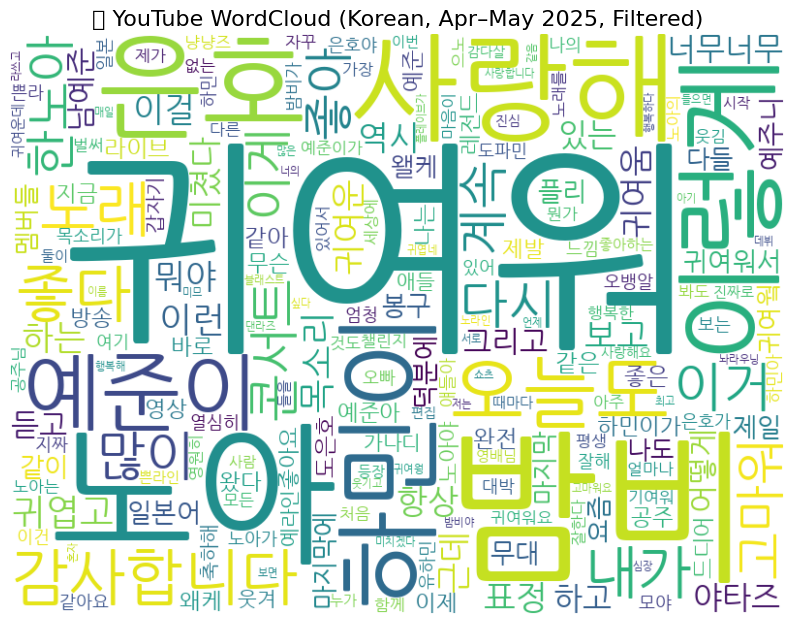

In [ ]:
# 1. Install NanumGothic font and reload matplotlib
!apt-get -qq install fonts-nanum
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')  # Set global font to NanumGothic
plt.rcParams['axes.unicode_minus'] = False  # Fix minus sign display

# 2. Imports
import pandas as pd
import re
from wordcloud import WordCloud
from datetime import datetime

df_filtered=df
# 6. Merge comments
text_data = " ".join(df_filtered["comment"].astype(str).tolist())

from collections import Counter

# 7. Clean text: remove emojis, symbols, keep Korean
def clean_text(text):
    text = re.sub(r"[^\uAC00-\uD7A3\s]", " ", text)  # keep only Korean
    text = re.sub(r"\s+", " ", text)
    return text.strip()

cleaned_text = clean_text(text_data)

# 8. Tokenize and filter
tokens = cleaned_text.split()

# Define words/phrases to exclude
excluded_words = set([
    "아니", "플레이브", "넘", "귀엽다", "정말", "오늘", "진짜", "그냥", "그거", "ㅋㅋ", "ㅎㅎ", "ㅠㅠ",'너무','미친','우리','하미니'
])

# Filter out: one-character + excluded words
filtered_tokens = [w for w in tokens if len(w) > 1 and w not in excluded_words]

# Count frequency
word_freq = Counter(filtered_tokens)

# 9. Generate word cloud
wordcloud = WordCloud(
    font_path='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    background_color='white',
    width=800,
    height=600
).generate_from_frequencies(word_freq)

# 10. Plot
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("📊 YouTube WordCloud (Korean, Apr–May 2025, Filtered)", fontsize=16)
plt.show()

## Complex version

In [ ]:
from sentence_transformers import SentenceTransformer


# Step 3: Fan slang normalization and custom stopwords
fan_slang_dict = {
    "스밍": "스트리밍", "플리": "팬", "재화": "포인트", "우주폰": "스밍폰",
    "공폰": "공용폰", "사과폰": "아이폰", "심괴": "심야괴담회",
    "멤버": "멤버", "뉴플리": "팬", "탈탈탈": "완전"
}

custom_stopwords = set([
    "정말", "그리고", "이번", "오늘", "내일", "하는", "있어요", "했습니다",
    "자기", "지금", "조금", "같아요", "ㅠㅠ", "ㅎㅎ", "ㅋㅋ", "더보기"
])

# Step 4: Preprocessing function
okt = Okt()

def preprocess_text(text):
    text = re.sub(r"[^\w\s]", " ", text)              # remove symbols/punctuation
    text = re.sub(r"\s+", " ", text)                  # normalize spaces
    text = re.sub(r"(.)\1{2,}", r"\1", text)          # reduce repeated chars
    for slang, norm in fan_slang_dict.items():
        text = text.replace(slang, norm)
    return text.strip()

# Apply preprocessing
df["cleaned"] = df["comment"].apply(preprocess_text)

# Tokenization + stopword filtering
df["tokens"] = df["cleaned"].apply(lambda x: [word for word in okt.morphs(x, stem=True)
                                              if word not in custom_stopwords and len(word) > 1])

# Re-join tokens into cleaned text (needed for BERTopic)
df["final_text"] = df["tokens"].apply(lambda x: " ".join(x))

# Step 5: Topic modeling with BERTopic
embedding_model = SentenceTransformer("snunlp/KR-SBERT-V40K-klueNLI-augSTS")  # Korean SBERT

from bertopic import BERTopic
from hdbscan import HDBSCAN

# Optional: pre-cleaned and tokenized text from previous step
cleaned_docs = df["tokens"].apply(lambda x: ' '.join(x)).tolist()

# HDBSCAN setup
hdbscan_model = HDBSCAN(min_cluster_size=30, min_samples=5, metric='euclidean')

# Topic model
topic_model = BERTopic(language="multilingual",
                       hdbscan_model=hdbscan_model,
                       top_n_words=8)
topics, probs = topic_model.fit_transform(cleaned_docs)

# Reduce number of topics for interpretability
topic_model.reduce_topics(cleaned_docs, nr_topics=10)

# View topics
topic_info = topic_model.get_topic_info()
topic_model.visualize_barchart(top_n_topics=10)

In [ ]:
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,9728,-1_하다_진짜_너무_보다,"[하다, 진짜, 너무, 보다, 좋다, 있다, 오다, 같다]","[아니다 근데 진짜 너무 하다 같다, 진짜 하다 귀엽다, 하다]"
1,0,16846,0_귀엽다_너무_하다_진짜,"[귀엽다, 너무, 하다, 진짜, 노아, 보다, 좋다, 밤비]","[귀엽다 귀엽다, 진짜 귀엽다 진짜 귀엽다 진짜 귀엽다 진짜 귀엽다 진짜 진짜 귀엽..."
2,1,986,1_귀엽다_너무_진짜_바부,"[귀엽다, 너무, 진짜, 바부, june, comming, single, soon]","[귀엽다, 귀엽다, 귀엽다]"
3,2,399,2_일본어_일본_하다_아시아,"[일본어, 일본, 하다, 아시아, 투어, 너무, 축하, 데뷔]","[일본어 하다, 일본어 하다 너무 귀엽다, 일본어 하다]"
4,3,351,3_사랑_하다_me_레이브,"[사랑, 하다, me, 레이브, 낭만, love, 자랑스럽다, leave]","[사랑 하다, 사랑 하다, 사랑 하다]"
5,4,139,4_최고_너무_좋다_재밌다,"[최고, 너무, 좋다, 재밌다, 최고다, 재미있다, 선택, woodz]","[너무 좋다, 너무 좋다, 너무 너무 좋다]"
6,5,66,5_기다리다_만을_오다_기다,"[기다리다, 만을, 오다, 기다, 언제나, 오래전, 에서, 고화질]","[기다리다, 기다리다, 기다리다]"
7,6,36,6_청춘_이다_컨셉_기대,"[청춘, 이다, 컨셉, 기대, 젊다, 도키, 어린이, 자체]","[청춘 이다, 청춘 이다, 청춘 이다]"
8,7,32,7_하다_있다_생각_마음,"[하다, 있다, 생각, 마음, 노래, 듣다, 예준, 사랑]",[축하 하다 우연히 들다 노래 너무 좋다 찾아보다 어떻다 방식 으로 추다 노래 부르...
9,8,31,8_충격_폭발_지진_동공,"[충격, 폭발, 지진, 동공, 이다, 도파민, 처음, 이란]","[오다 충격 이다, 충격, 충격 이다]"
